# PLAN_B — Zero-shot transfer of frozen cnnNoROI to RAM-H1200

Validates the COCO adapter (`src/prepare_ramh1200_boxes.py`) on a small subset,
runs Stage-1 MedSAM, re-derives the gating threshold, runs the frozen
`cnnNoROI` experts (no retraining), and evaluates MedSAM baseline vs
MedSAM+frozen-experts. See `PLAN_B.md` for the full experiment design.

Run with the `MoE` conda env (`conda activate MoE`) as the kernel.


## 1. Setup

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
WORKSPACE_ROOT = REPO_ROOT.parent
MEDSAM_REPO_ROOT = WORKSPACE_ROOT / "MedSAM"

for p in (REPO_ROOT / "src", MEDSAM_REPO_ROOT):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from prepare_ramh1200_boxes import process_split
from run_medsam_with_pengwin_boxes import load_and_preprocess_image, run_medsam_with_boxes
from sdf_utils import sdf_channel_from_mask
from dataloader_utils import load_prediction_masks

from segment_anything import sam_model_registry

DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

DATASET_ROOT = REPO_ROOT / "RAM-H1200-v1_dataset" / "Segmentation"
BOXES_ROOT = REPO_ROOT / "data" / "ramh1200" / "bounding-boxes"
MEDSAM_PRED_ROOT = REPO_ROOT / "data" / "ramh1200" / "medsam-predictions"
MOE_PRED_ROOT = REPO_ROOT / "data" / "ramh1200" / "moe-predictions"
CHECKPOINT_DIR = REPO_ROOT / "checkpoints" / "cnnNoROI"
MEDSAM_CHECKPOINT = MEDSAM_REPO_ROOT / "medsam_vit_b.pth"

SPLIT = "test"
SMOKE_LIMIT = None  # full split


/Users/ioana/anaconda3/envs/MoE/lib/python3.10/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/Users/ioana/anaconda3/envs/MoE/lib/python3.10/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <0B7EB158-53DC-3403-8A49-22178CAB4612> /Users/ioana/anaconda3/envs/MoE/lib/python3.10/site-packages/torchvision/image.so
  Reason: tried: '/Users/ioana/anaconda3/envs/MoE/lib/python3.10/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/ioana/anaconda3/envs/MoE/lib/python3.10/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/ioana/anaconda3/envs/MoE/lib/python3.10/lib-dynload/../../libjpeg.9.dylib' (no such file), '/Users/ioana/anaconda3/envs/MoE/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your e

device: mps


## 2. Build boxes + GT masks for a small subset (adapter validation)

In [2]:
process_split(
    dataset_root=DATASET_ROOT,
    output_root=BOXES_ROOT,
    split=SPLIT,
    image_size=1024,
    limit=SMOKE_LIMIT,
)

records = [json.loads(l) for l in (BOXES_ROOT / SPLIT / "metadata.jsonl").open()]
print(f"{len(records)} records")
records[0]["sample_name"], records[0]["num_fragments"]


[test] RAM-H1200 boxes:   0%|          | 0/267 [00:00<?, ?it/s]

[test] RAM-H1200 boxes:   1%|          | 2/267 [00:00<00:24, 10.86it/s]

[test] RAM-H1200 boxes:   1%|▏         | 4/267 [00:00<00:23, 11.10it/s]

[test] RAM-H1200 boxes:   2%|▏         | 6/267 [00:00<00:23, 11.08it/s]

[test] RAM-H1200 boxes:   3%|▎         | 8/267 [00:00<00:23, 10.96it/s]

...

[test] RAM-H1200 boxes:  99%|█████████▉| 265/267 [00:27<00:00,  9.85it/s]

[test] RAM-H1200 boxes: 100%|██████████| 267/267 [00:27<00:00, 10.13it/s]

[test] RAM-H1200 boxes: 100%|██████████| 267/267 [00:27<00:00,  9.54it/s]

[test] wrote 267 records to /Users/ioana/Desktop/FOMO/MoE-ShapeRefine-MedicalSeg/data/ramh1200/bounding-boxes/test/metadata.jsonl
267 records


('RAMH1200_test_JP_HMCRD_P0060_20210415_7522_L', 31)

## 3. Visualize GT overlays — confirm masks + boxes line up with anatomy

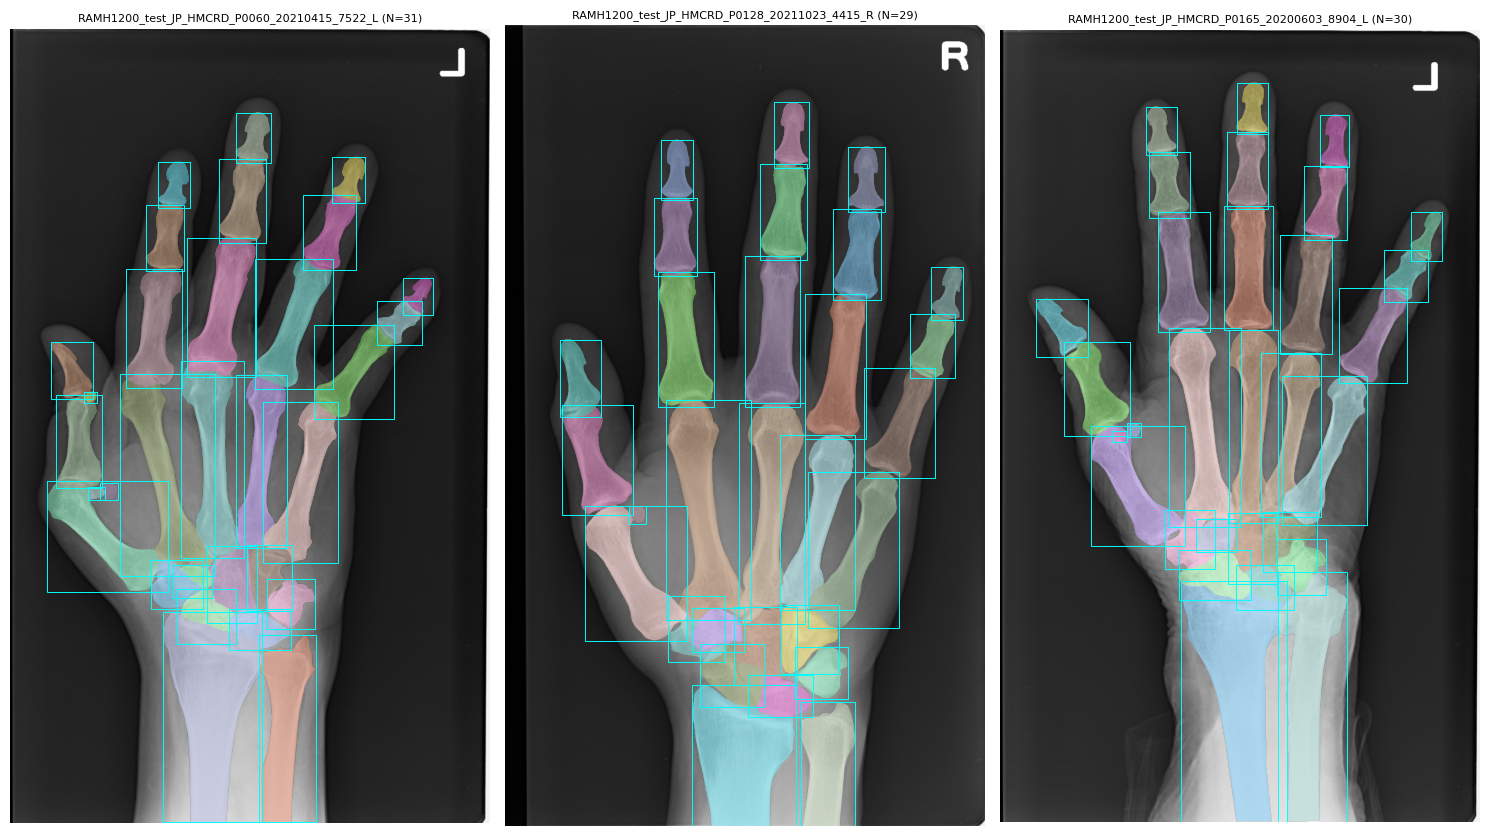

In [3]:
def show_gt_overlay(record, ax=None):
    image = np.array(Image.open(record["original_image_path"]).convert("L"))
    gt_masks = np.load(record["gt_masks_path"])["masks"]  # (N, H, W) original res

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 9))
    ax.imshow(image, cmap="gray")

    overlay = np.zeros((*image.shape, 4))
    rng = np.random.default_rng(0)
    for i in range(gt_masks.shape[0]):
        color = rng.uniform(0.3, 1.0, size=3)
        m = gt_masks[i].astype(bool)
        overlay[m] = [*color, 0.45]
    ax.imshow(overlay)

    for frag in record["fragments"]:
        x1, y1, x2, y2 = frag["bbox_xyxy"]
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="cyan", linewidth=0.7))

    ax.set_title(f"{record['sample_name']} (N={record['num_fragments']})", fontsize=8)
    ax.axis("off")


fig, axes = plt.subplots(1, 3, figsize=(15, 9))
for ax, record in zip(axes, records[:3]):
    show_gt_overlay(record, ax=ax)
plt.tight_layout()
plt.show()


## 4. Stage-1 MedSAM inference

Reuses the existing PENGWIN preprocessing (neglog + quantile window [0.01, 0.95]
+ resize to 1024) and box-prompted MedSAM inference unchanged, per PLAN_B —
this keeps the embedding distribution as close as possible to what the frozen
experts were trained on.

In [4]:
model = sam_model_registry["vit_b"](checkpoint=str(MEDSAM_CHECKPOINT))
model = model.to(DEVICE)
model.eval()
print("loaded MedSAM base checkpoint:", MEDSAM_CHECKPOINT)


/Users/ioana/Desktop/FOMO/MedSAM/segment_anything/build_sam.py:144: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f, map_location=torch.device('cpu')

loaded MedSAM base checkpoint: /Users/ioana/Desktop/FOMO/MedSAM/medsam_vit_b.pth


In [5]:
binary_masks_dir = MEDSAM_PRED_ROOT / SPLIT / "binary_masks"
embeddings_dir = MEDSAM_PRED_ROOT / SPLIT / "embeddings"
binary_masks_dir.mkdir(parents=True, exist_ok=True)
embeddings_dir.mkdir(parents=True, exist_ok=True)

medsam_pred_records = []
for record in records:
    image = load_and_preprocess_image(record["original_image_path"], image_size=record["image_size"])
    boxes = np.load(record["box_path"]).astype(np.float32)

    binary_masks, embedding = run_medsam_with_boxes(model, image, boxes, DEVICE, threshold=0.5)

    sample_name = record["sample_name"]
    masks_path = binary_masks_dir / f"{sample_name}.npz"
    embedding_path = embeddings_dir / f"{sample_name}.npy"
    np.savez_compressed(masks_path, masks=binary_masks)
    np.save(embedding_path, embedding)

    medsam_pred_records.append({
        **record,
        "binary_masks_path": str(masks_path.resolve()),
        "embedding_path": str(embedding_path.resolve()),
    })

pred_metadata_path = MEDSAM_PRED_ROOT / SPLIT / "metadata.jsonl"
pred_metadata_path.parent.mkdir(parents=True, exist_ok=True)
with pred_metadata_path.open("w") as f:
    for r in medsam_pred_records:
        f.write(json.dumps(r) + "\n")

print(f"wrote {len(medsam_pred_records)} MedSAM prediction records to {pred_metadata_path}")


wrote 267 MedSAM prediction records to /Users/ioana/Desktop/FOMO/MoE-ShapeRefine-MedicalSeg/data/ramh1200/medsam-predictions/test/metadata.jsonl


## 5. Sanity-check MedSAM baseline masks visually

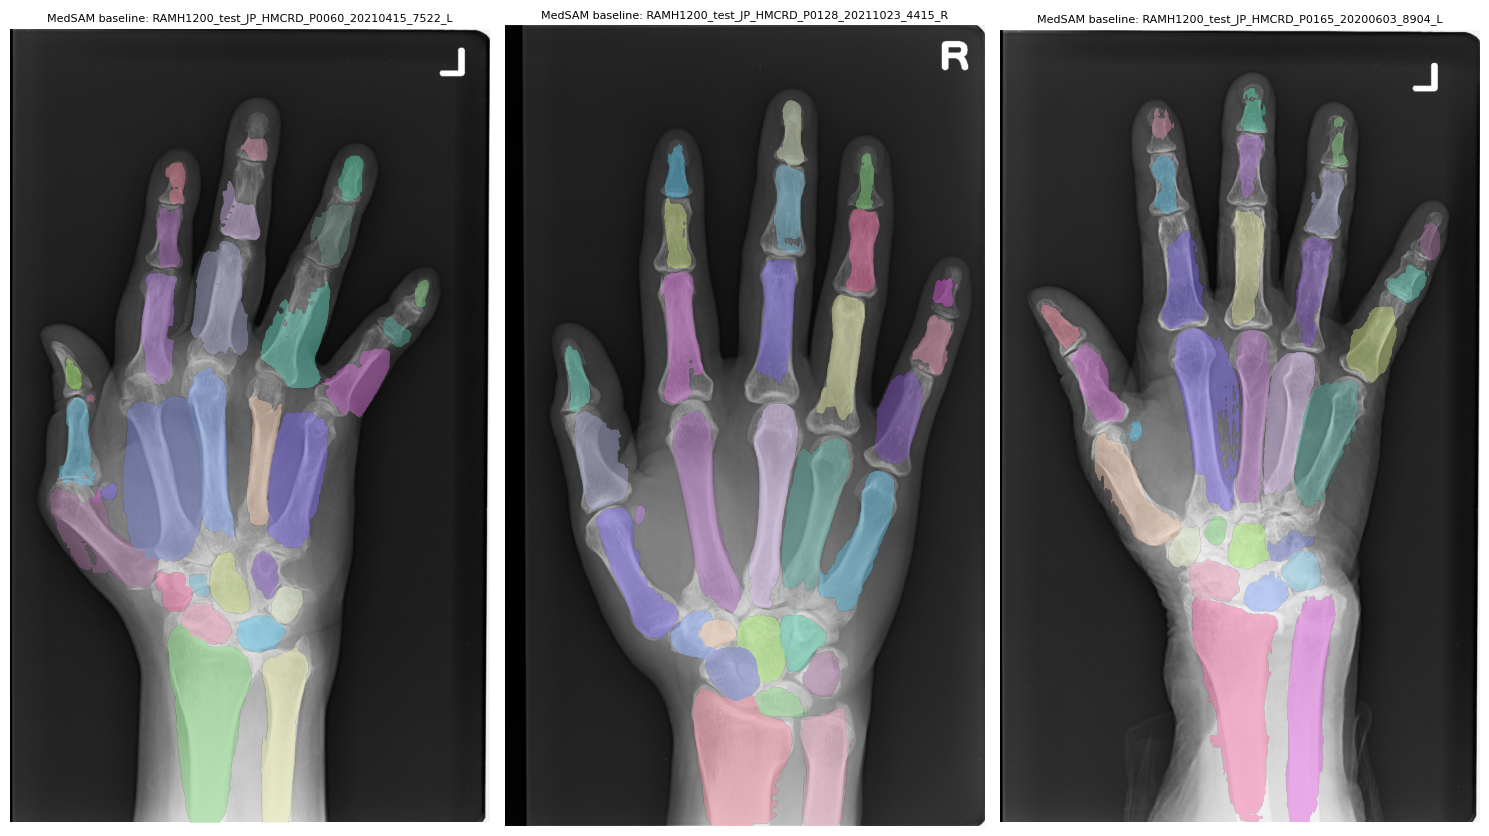

In [6]:
def show_pred_overlay(record, ax=None, title_prefix=""):
    image = np.array(Image.open(record["original_image_path"]).convert("L"))
    pred_masks = load_prediction_masks(record["binary_masks_path"])  # (N, 1024, 1024)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 9))
    ax.imshow(image, cmap="gray")

    # resize the 1024-grid image to overlay coordinates for display
    h, w = image.shape
    overlay = np.zeros((*pred_masks.shape[1:], 4))
    rng = np.random.default_rng(1)
    for i in range(pred_masks.shape[0]):
        color = rng.uniform(0.3, 1.0, size=3)
        m = pred_masks[i].astype(bool)
        overlay[m] = [*color, 0.45]
    ax.imshow(overlay, extent=(0, w, h, 0))
    ax.set_title(f"{title_prefix}{record['sample_name']}", fontsize=8)
    ax.axis("off")


fig, axes = plt.subplots(1, 3, figsize=(15, 9))
for ax, record in zip(axes, medsam_pred_records[:3]):
    show_pred_overlay(record, ax=ax, title_prefix="MedSAM baseline: ")
plt.tight_layout()
plt.show()


## 6. Re-derive the gating threshold on RAM-H1200

The PENGWIN threshold (5402 px on the 1024 grid) is meaningless here — bone
sizes differ completely from pelvis fragments. Use the median predicted-mask
area on this dataset instead (the same convention `evaluate_medsam_pengwin.py`
already falls back to when no `--area-threshold` is given), and report the
resulting small/large split.

In [7]:
areas = []
for record in medsam_pred_records:
    masks = load_prediction_masks(record["binary_masks_path"])
    for i in range(masks.shape[0]):
        areas.append(int(masks[i].sum()))

areas = np.array(areas)
ram_h1200_threshold = float(np.median(areas))
print(f"n fragments: {len(areas)}")
print(f"RAM-H1200 area threshold (median predicted-mask area, px on 1024 grid): {ram_h1200_threshold:.1f}")
print(f"(for reference, PENGWIN threshold was 5402 px)")

def route_to_expert(area, threshold=ram_h1200_threshold):
    return "expert_small" if area <= threshold else "expert_large"

gated_rows = []
for record in medsam_pred_records:
    masks = load_prediction_masks(record["binary_masks_path"])
    for frag, mask in zip(record["fragments"], masks):
        area = int(mask.sum())
        gated_rows.append({
            "sample_name": record["sample_name"],
            "medsam_instance_id": frag["medsam_instance_id"],
            "category_name": frag["category_name"],
            "area": area,
            "expert": route_to_expert(area),
            "embedding_path": record["embedding_path"],
            "binary_masks_path": record["binary_masks_path"],
        })

import pandas as pd
gated_df = pd.DataFrame(gated_rows)
gating_dir = REPO_ROOT / "src" / "gating_mechanism"
gated_csv_path = gating_dir / f"gated_ramh1200_{SPLIT}_records.csv"
gated_df.to_csv(gated_csv_path, index=False)
print(f"saved {len(gated_df)} gated fragments -> {gated_csv_path}")
print(gated_df["expert"].value_counts().to_string())


n fragments: 7857
RAM-H1200 area threshold (median predicted-mask area, px on 1024 grid): 3990.0
(for reference, PENGWIN threshold was 5402 px)


saved 7857 gated fragments -> /Users/ioana/Desktop/FOMO/MoE-ShapeRefine-MedicalSeg/src/gating_mechanism/gated_ramh1200_test_records.csv
expert
expert_small    3929
expert_large    3928


## 7. Run frozen `cnnNoROI` experts (no retraining)

Requires the PENGWIN-trained checkpoints at
`checkpoints/cnnNoROI/expert_small_best.pth` and `expert_large_best.pth`. If
you haven't copied them onto this machine yet, this cell will raise
`FileNotFoundError` — copy them in and re-run from here.

In [8]:
from cnnNoROI.cnnMoE import CNNExpert
import torch.nn.functional as F

FEAT_SIZE = 64
OUTPUT_SIZE = 1024

def load_expert(checkpoint_path, device):
    model = CNNExpert(c_in=258).to(device)
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    return model

experts = {}
for expert_id in ("expert_small", "expert_large"):
    ckpt_path = CHECKPOINT_DIR / f"{expert_id}_best.pth"
    if not ckpt_path.exists():
        raise FileNotFoundError(
            f"Checkpoint not found: {ckpt_path}\n"
            f"Copy the PENGWIN-trained cnnNoROI checkpoints into {CHECKPOINT_DIR} and re-run this cell."
        )
    experts[expert_id] = load_expert(ckpt_path, DEVICE)
    print(f"loaded {expert_id} from {ckpt_path}")


loaded expert_small from /Users/ioana/Desktop/FOMO/MoE-ShapeRefine-MedicalSeg/checkpoints/cnnNoROI/expert_small_best.pth
loaded expert_large from /Users/ioana/Desktop/FOMO/MoE-ShapeRefine-MedicalSeg/checkpoints/cnnNoROI/expert_large_best.pth


In [9]:
@torch.no_grad()
def refine_fragment(embedding, binary_mask, model, device):
    mask_t = torch.from_numpy(binary_mask.astype(np.float32)).unsqueeze(0).unsqueeze(0).to(device)
    mask_small = F.interpolate(mask_t, size=(FEAT_SIZE, FEAT_SIZE), mode="nearest")

    sdf_np = sdf_channel_from_mask(mask_small[0, 0].cpu().numpy())
    sdf = torch.from_numpy(sdf_np).unsqueeze(0).to(device)

    x = torch.cat([embedding.unsqueeze(0), mask_small, sdf], dim=1)
    pred = model(x)

    pred_up = F.interpolate(pred, size=(OUTPUT_SIZE, OUTPUT_SIZE), mode="bilinear", align_corners=False)
    return (pred_up[0, 0].cpu().numpy() > 0.5).astype(np.uint8)


moe_masks_dir = MOE_PRED_ROOT / SPLIT / "binary_masks"
moe_masks_dir.mkdir(parents=True, exist_ok=True)

for sample_name in gated_df["sample_name"].unique():
    rows = gated_df[gated_df["sample_name"] == sample_name].sort_values("medsam_instance_id").reset_index(drop=True)

    embedding = torch.from_numpy(np.load(rows.iloc[0]["embedding_path"])).float().to(DEVICE)
    all_masks = load_prediction_masks(rows.iloc[0]["binary_masks_path"])

    refined = []
    for _, row in rows.iterrows():
        idx = int(row["medsam_instance_id"]) - 1
        binary_mask = all_masks[idx]
        model = experts[row["expert"]]
        refined.append(refine_fragment(embedding, binary_mask, model, DEVICE))

    out_masks = np.stack(refined)
    np.savez_compressed(moe_masks_dir / f"{sample_name}.npz", masks=out_masks)

print(f"refined masks written to {moe_masks_dir}")


refined masks written to /Users/ioana/Desktop/FOMO/MoE-ShapeRefine-MedicalSeg/data/ramh1200/moe-predictions/test/binary_masks


## 8. Evaluate: MedSAM baseline vs. MedSAM + frozen cnnNoROI

Reuses the exact dice/iou/hd95/assd implementations from
`evaluation/evaluate_medsam_pengwin.py` (they're PENGWIN-format-agnostic —
just take two binary masks).

In [10]:
sys.path.insert(0, str(REPO_ROOT))
from evaluation.evaluate_medsam_pengwin import dice_score, iou_score, boundary_metrics
from dataloader_utils import resize_binary_nearest

def evaluate_predictions(pred_masks_dir, gated_df, area_threshold, skip_boundary=False):
    rows = []
    for record in medsam_pred_records:
        sample_name = record["sample_name"]
        gt_masks = np.load(record["gt_masks_path"])["masks"]  # (N, H, W) original res
        pred_path = pred_masks_dir / f"{sample_name}.npz"
        pred_masks = load_prediction_masks(pred_path)  # (N, 1024, 1024)

        frag_expert = {
            int(r["medsam_instance_id"]): r["expert"]
            for _, r in gated_df[gated_df["sample_name"] == sample_name].iterrows()
        }

        for i, frag in enumerate(record["fragments"]):
            gt = gt_masks[i]
            pred = resize_binary_nearest(pred_masks[i], gt.shape)

            dice = dice_score(pred, gt)
            iou = iou_score(pred, gt)
            hd95, assd = (np.nan, np.nan) if skip_boundary else boundary_metrics(pred, gt)

            mask_area = int(pred_masks[i].astype(bool).sum())
            rows.append({
                "sample_name": sample_name,
                "category_name": frag["category_name"],
                "size_group": frag_expert.get(frag["medsam_instance_id"], "unknown"),
                "dice": dice, "iou": iou, "hd95": hd95, "assd": assd,
            })
    return pd.DataFrame(rows)


baseline_df = evaluate_predictions(MEDSAM_PRED_ROOT / SPLIT / "binary_masks", gated_df, ram_h1200_threshold)
moe_df = evaluate_predictions(moe_masks_dir, gated_df, ram_h1200_threshold)

print("MedSAM baseline (overall):")
print(baseline_df[["dice", "iou", "hd95", "assd"]].mean())
print("\nMedSAM + frozen cnnNoROI (overall):")
print(moe_df[["dice", "iou", "hd95", "assd"]].mean())

print("\nMedSAM baseline by size group:")
print(baseline_df.groupby("size_group")[["dice", "iou", "hd95", "assd"]].mean())
print("\nMedSAM + frozen cnnNoROI by size group:")
print(moe_df.groupby("size_group")[["dice", "iou", "hd95", "assd"]].mean())


MedSAM baseline (overall):
dice     0.743578
iou      0.610860
hd95    24.721142
assd     8.659535
dtype: float64

MedSAM + frozen cnnNoROI (overall):
dice     0.656543
iou      0.509303
hd95    43.871712
assd    15.283823
dtype: float64

MedSAM baseline by size group:
                  dice       iou       hd95      assd
size_group                                           
expert_large  0.805606  0.688179  26.428971  8.922495
expert_small  0.681567  0.533560  23.011137  8.396241

MedSAM + frozen cnnNoROI by size group:
                  dice       iou       hd95       assd
size_group                                            
expert_large  0.637132  0.489472  56.750901  19.361231
expert_small  0.675950  0.529129  30.700501  11.113964


## 9. Next steps

- If the smoke test (N=15) looks sane — GT overlays match anatomy, MedSAM
  baseline masks are reasonable, refined masks load and evaluate — bump
  `SMOKE_LIMIT` to `None` (or a larger number) and re-run from Section 2 for
  the full `test` split.
- Consider running `train`/`val` splits too if a larger sample is wanted for
  the final report.
- Report the routing split (Section 6) and the before/after delta (Section 8)
  honestly per PLAN_B section 6 — positive delta is a generalization result,
  flat/negative is still a reportable, informative result.

## 10. Where are we off? GT vs. MedSAM baseline vs. frozen-expert-refined

Full test-set numbers (267 images, 7857 fragments):

| | dice | iou | hd95 | assd |
|---|---|---|---|---|
| MedSAM baseline | 0.744 | 0.611 | 24.7 | 8.7 |
| MedSAM + frozen cnnNoROI | 0.657 | 0.509 | 43.9 | 15.3 |

By size group, the regression is concentrated in `expert_large`
(dice 0.806 → 0.637, hd95 26.4 → 56.8) while `expert_small` is closer to flat
(dice 0.682 → 0.676). The zero-shot transfer does not hold here.

Below: the per-image case with the **worst** dice regression, and the
**median** (typical) case — not a cherry-picked improvement — so the failure
mode is visible rather than papered over.

worst regression: RAMH1200_test_JP_HMCRD_P0117_20210323_8517_R (delta=-0.218)
median/typical:   RAMH1200_test_JP_HMCRD_P0133_20210111_5743_R (delta=-0.089)


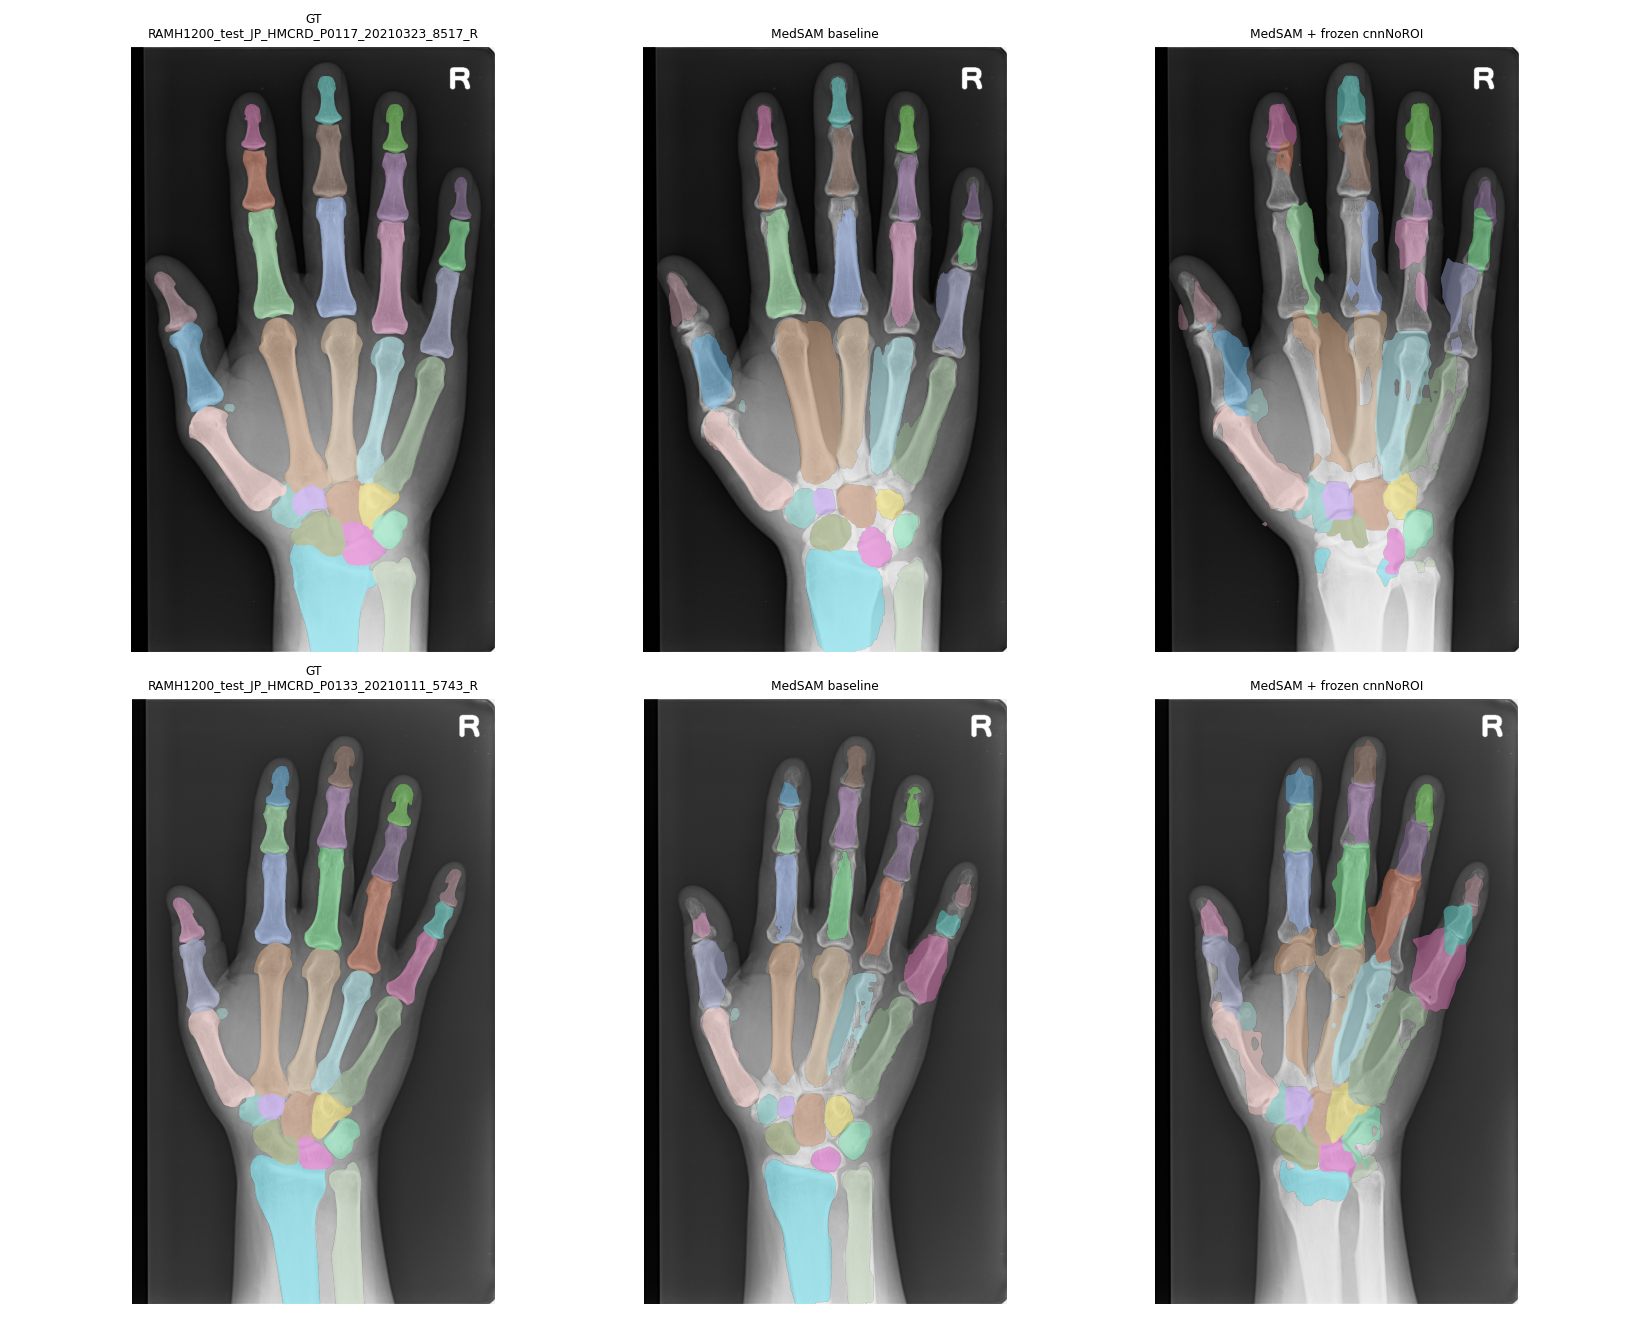

In [21]:
import io
from evaluation.evaluate_medsam_pengwin import dice_score

# Rank every test image by (refined_dice - baseline_dice) to find a
# representative failure case and the median (typical) case.
delta_rows = []
for record in records:
    sample_name = record["sample_name"]
    gt_masks = np.load(record["gt_masks_path"])["masks"]
    baseline_masks = load_prediction_masks(MEDSAM_PRED_ROOT / SPLIT / "binary_masks" / f"{sample_name}.npz")
    moe_masks = load_prediction_masks(moe_masks_dir / f"{sample_name}.npz")

    base_dices, moe_dices = [], []
    for i in range(gt_masks.shape[0]):
        gt = gt_masks[i]
        base_dices.append(dice_score(resize_binary_nearest(baseline_masks[i], gt.shape), gt))
        moe_dices.append(dice_score(resize_binary_nearest(moe_masks[i], gt.shape), gt))

    delta_rows.append({
        "sample_name": sample_name,
        "base_dice": np.mean(base_dices),
        "moe_dice": np.mean(moe_dices),
        "delta": np.mean(moe_dices) - np.mean(base_dices),
    })

delta_df = pd.DataFrame(delta_rows).sort_values("delta").reset_index(drop=True)
worst_case = delta_df.iloc[0]["sample_name"]
median_case = delta_df.iloc[len(delta_df) // 2]["sample_name"]
print(f"worst regression: {worst_case} (delta={delta_df.iloc[0]['delta']:.3f})")
print(f"median/typical:   {median_case} (delta={delta_df.iloc[len(delta_df)//2]['delta']:.3f})")

records_by_name = {r["sample_name"]: r for r in records}

def colorize(masks, rng_seed=0):
    overlay = np.zeros((*masks.shape[1:], 4))
    rng = np.random.default_rng(rng_seed)
    for i in range(masks.shape[0]):
        color = rng.uniform(0.3, 1.0, size=3)
        m = masks[i].astype(bool)
        overlay[m] = [*color, 0.45]
    return overlay

fig, axes = plt.subplots(2, 3, figsize=(15, 12))
for row, sample_name in enumerate([worst_case, median_case]):
    record = records_by_name[sample_name]
    image = np.array(Image.open(record["original_image_path"]).convert("L"))
    h, w = image.shape

    gt_masks = np.load(record["gt_masks_path"])["masks"]
    baseline_masks = load_prediction_masks(MEDSAM_PRED_ROOT / SPLIT / "binary_masks" / f"{sample_name}.npz")
    moe_masks = load_prediction_masks(moe_masks_dir / f"{sample_name}.npz")

    for col, (masks, title) in enumerate([
        (gt_masks, "GT"),
        (baseline_masks, "MedSAM baseline"),
        (moe_masks, "MedSAM + frozen cnnNoROI"),
    ]):
        ax = axes[row, col]
        ax.imshow(image, cmap="gray", extent=(0, w, h, 0))
        ax.imshow(colorize(masks), extent=(0, w, h, 0))
        ax.set_title(f"{title}\n{sample_name}" if col == 0 else title, fontsize=8)
        ax.axis("off")

plt.tight_layout()
plt.show()
